#  <span style="color:green">Tutorial - Particle Path SLAM</span>

This tutorial implements Particle Path SLAM (ppSLAM) for 2D localisation and mapping using a feature-less map representation (B2.3). Key differences to standard particle filters (PF) are:

- Map observations along particle path histories are stored by each particle
- In reobserved areas, particle weights are computed using Gaussian process regression models trained on past observations. 

Re-sampling is identical to a standard PF, but particles with large weights (i.e., high new-observation likelhoods) spawn child particles that inherit their path maps. The fact that observation consistency is based on past observations that are stored in the maps means that the method is a smoother, solving the full-SMAL problem.

The basic structure of the tutorial is as follows:

<img src="images/B2_3_Tutorial_Overview.png" alt="Particle Path SLAM" width="600px" align="center"/>

The tutorial builds on motion models and observation models discussed in previous tutorials, where knowledge of these will assumed.

##  <span style="color:green">Simulating the environment and sensing</span>

To develop ppSLAM, we first build a simple map environment for the robot to move in and observe. We reuse the following functions that we already dealt with in previous tutorials.

**Environment:** 
- `build_square_environment()`: builds a square 2D environment that can be observed by sensors

**Sensing:** A range bearing lidar based on A1.3, extended to generate range poportional noise on the measurements as in B2.2 graphSLAM. 
- `lidar_scan()`: Simulates a lidar scan with a prescribed number of beams, given a pose, environment and lidar parameters. The environment only needs to be known for simulation purposes and ppSLAM only uses observations of (range, theta).
- `plot_scan()`: Plots the observations, FOV and pose of the robot

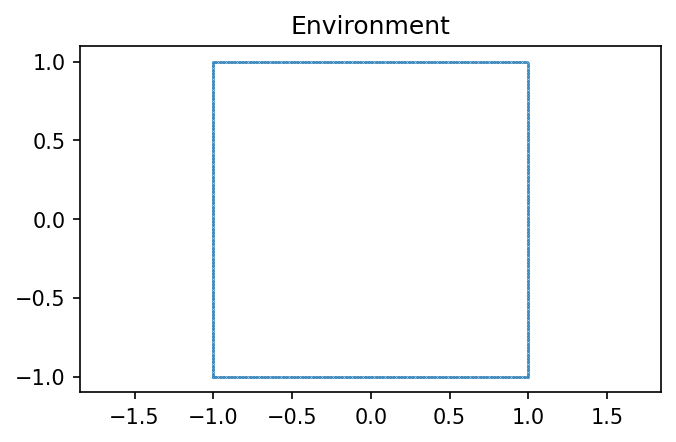

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math_feeg6043 import Vector, Matrix, HomogeneousTransformation, polar2cartesian
from plot_feeg6043 import show_observation,plot_2dframe, show_scan
from model_feeg6043 import build_square_environment, lidar_scan, rigid_body_kinematics

environment_map = build_square_environment(edge_length=2,resolution=0.01)
m_y=environment_map[:,1].T
m_x=environment_map[:,0].T

Below we use these functions to plot observations from a known pose. 
- p = $[-0.8, -0.1, 270^o]^T$

We locate a lidar at the robot centre of rotation (for convenience) and properties 
- Range = [0.1 to 1] m
- FOV = 90 deg, 30 beams
- The observation model assumes 1% of range 

In [2]:
# Create a function that, given a position and a map, returns the range and bearing of
# the edges of the map, assuming a FOV of 90 degrees, a maximum range of 1 meter and
# a total of 90 measurements.
######################## Set the robot pose b in the e frame ##################
p = Vector(3); 

p[0] = -0.8; p[1] = -0.1; p[2] = np.deg2rad(270)  #Northings; Eastings; Heading (rad)
print('3x1 state vector:\n',p,'\n')
H_eb = HomogeneousTransformation(p[0:2],p[2])
#############################################################################

######################## Observation model ##################
from model_feeg6043 import RangeAngleKinematics
# locate lidar on robot (keep it simple)
x_bl = 0; y_bl = 0
t_bl = Vector(2)
t_bl[0] = x_bl; t_bl[1] = y_bl
H_bl = HomogeneousTransformation(t_bl,0)

#########observation model linear noise with range###############
sigma_observe = Matrix(2,2)
sigma_observe[0,0] = 0.01 #1% of range
sigma_observe[0,1] = 0
sigma_observe[1,0] = np.deg2rad(1) #1 degree per metre range
sigma_observe[1,1] = 0
print('2x2 measurement noise model:\n',sigma_observe,'\n')

# use Class from A1.3
lidar = RangeAngleKinematics(x_bl, y_bl, distance_range = [0.1, 1], scan_fov = np.deg2rad(90), n_beams = 30) #Task
#################################################################

3x1 state vector:
 [[-0.8       ]
 [-0.1       ]
 [ 4.71238898]] 

2x2 measurement noise model:
 [[0.01       0.        ]
 [0.01745329 0.        ]] 

*******************************************************************************************
Sensor located at: [0.] [0.] m offset, at angle: 0.0 deg to the body
Measurement range is between: [0.1, 1] m
Scanning field of view is: 90.0 deg
Number of beams per scan is: 30
*******************************************************************************************


Make a scan and plot it on the map

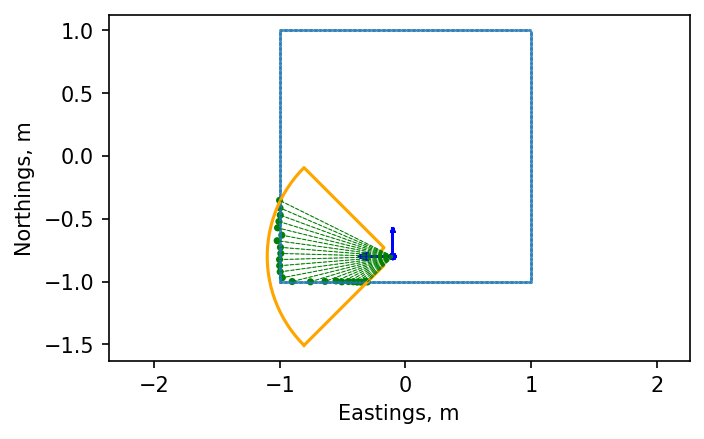

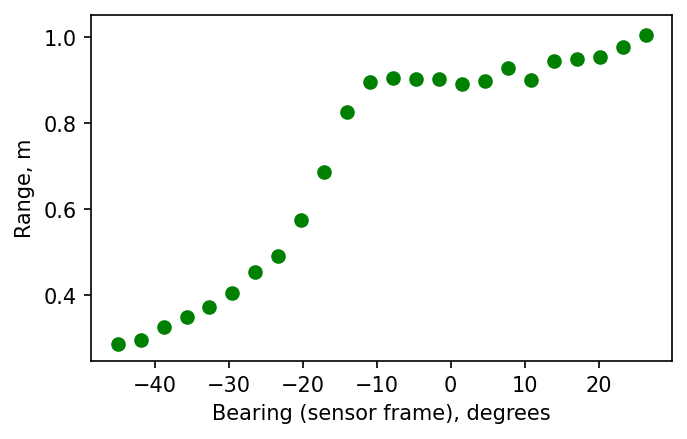

In [3]:
# compute observations with noise
observations, observations_std = lidar_scan(p, environment_map, lidar, sigma_observe)    

# plot scan in the environment frame
fig,ax = plt.subplots()
show_scan(p, lidar, observations, ax)
ax.scatter(m_y,m_x,s=0.1)
plt.show()

# plot the raw sensor readings
plt.errorbar(np.rad2deg(observations[:, 1]), observations[:, 0], yerr=observations_std[:,0], c = 'g', fmt='o', label='Observations')
plt.xlabel('Bearing (sensor frame), degrees')
plt.ylabel('Range, m')
plt.show()

##  <span style="color:green">Particles for full-SLAM</span>

**Basic particles:**
The prediction step of a particle filter applies a motion model with sampled noise acting on each particle. We implement this in our PF, which is similar to that in `pf.ipynb`. 

The differences are: 
- Map observations are stored (in the $e$ frame), as auxilliary variables. The uncertainty will be modelled using GPRs outside of the particles.
- A sensor model is stored. This is to convert map observations into sensor readings to compare map predicted observations with new observations. The could be stored outside the particle class, but is useful to interpret map observations from within the same particle.

In [4]:
from sklearn.neighbors import KernelDensity 
from model_feeg6043 import ParticleMap
from model_feeg6043 import ParticlePathSLAM

class ParticleMap:
    __slots__ = (        
        "x",
        "y",
        "gamma",
        "sensor",
        "fov",
        "range",
        "weight",
        "observations", # map
        "auxilliary_noise",
        "jitter",
    )

    def __init__(
        self,
        sensor,         
        x=0.0,
        y=0.0,
        gamma=0.0,
        num_particles=1,
        auxilliary_noise=[np.deg2rad(5), 0.01, np.deg2rad(3)], # Task       
        jitter=0.1 # Task
        
    ):
        """_summary_

        Parameters
        ----------
        sensor: RangeAngleKinematics, class
            FOV, lidar location and measurement range        
        x : float, optional
            Starting x position (northings) in meters, by default 0.0
        y : float, optional
            Starting y position (eastings) in meters, by default 0.0
        gamma : float, optional
            Starting orientation in radians, by default 0.0
        num_particles : int, optional
            The number of particles, by default 1
        auxilliary_noise : list, optional
            Auxilliary parameter noise as a list for gamma, x dot, gamma dot, by default [np.deg2rad(1), 0.01, np.deg2rad(0.1)]
        
        """
        # Robot state: [timestamp, x, y, gamma]
        self.x = x
        self.y = y
        self.gamma = gamma % (2 * np.pi)
        self.sensor = sensor
        self.jitter = jitter

        # Weight
        self.weight = 1.0 / num_particles
        
        # Observations
        self.observations = None        

        # Noise        
        self.auxilliary_noise = auxilliary_noise

        # Apply Gaussian noise to the robot state
        self.initialise()

    def add_observations(self, new_observations_rb):
        """Adds new observations to the particle

        Parameters
        ----------
        new_observations_rb : np.ndarray
            Array containing (range, bearing) for all measurements.
        """
        for obs in new_observations_rb:
            obs_xy = self.sensor.rangeangle_to_loc(self.pose, obs) # Task
            if self.observations is None:
                self.observations = np.array([obs_xy])
            else:
                self.observations = np.append(self.observations, [obs_xy], axis=0)    # Task

    def initialise(self):
        # Apply Gaussian noise to the robot state when resampling and inherit path
        
        theta = np.random.uniform(0, np.deg2rad(360))
        r = np.sqrt(np.random.uniform(0, 1)) * self.jitter

        northings_std, eastings_std = polar2cartesian(r,theta)           
        
        self.x = self.x + northings_std
        self.y = self.y + eastings_std
        self.gamma = np.random.normal(self.gamma, self.auxilliary_noise[0]) % (2 * np.pi)

    def predict(self, u, dt = 1):
        """
        Sample next state X_t from current state X_t-1 and control U_t with
        added auxilliary_noise noise.

        Based on discrete auxilliary_noise model

        Input:
            u: control input (twist).
                     [v, w]
            dt: float options, timestep        
        """
        p = Vector(3)
            
        # noise is not added to the location of the particles as the distribution already represents the noise and this is what our PF will update based on sensor observations
        p[0] = self.x
        p[1] = self.y

        # We treat the other states differently, where noise is random sampled from a distribution and added   
        p[2] = self.gamma + np.random.normal(scale=self.auxilliary_noise[0]) % (2*np.pi)               

        u_noise = Vector(2)
        u_noise[0] = u[0] + np.random.normal(scale=self.auxilliary_noise[1])
        u_noise[1] = u[1] + np.random.normal(scale=self.auxilliary_noise[2])
            
        # note rigid_body_kinematics already handles the exception dynamics of w=0

        p,_,_,_ = rigid_body_kinematics(p,u_noise,dt)    
        
        # update the particles and store the information
        self.x = p[0,0]
        self.y = p[1,0]
        self.gamma = p[2,0] % (2*np.pi)                          

    @property
    def pose(self):      
        pose = Vector(3)
        
        pose[0]=self.x
        pose[1]=self.y
        pose[2]=self.gamma
        
        return pose
    
    @pose.setter
    def pose(self, pose):
        self.x = pose[0,0]
        self.y = pose[1,0]
        # self.gamma = pose[2,0] % (2 * np.pi)     

    @property
    def observations_rangeangle(self):
        """Returns past observations in the robot frame as (range, bearing)."""
        if self.observations is None:
            return None
        rangeangles = []
        for obs in self.observations:
            z_lm , _ , _ , _ = self.sensor.loc_to_rangeangle(self.pose, obs) # Task
            rangeangles.append(z_lm.T[0 ])
        rangeangles = np.array(rangeangles)
        return rangeangles

**Path SLAM:** More advance functionality exist in a ParticlePathSLAM class, which deals with weight updates and resampling needed for particle path SLAM and visualisation. This deals with:
- kde sampling from weighted particle distribution
- computation of weights
- computation of particle efficiency based on weight distribution
- resampling of particles

Where the observation Likelihood is:

\begin{eqnarray}
w^{[n]}_k = w^{[n]}_{k-1} p(\mathbf{z}_{est}=\mathbf{z}_{obs})= w^{[n]}_{k-1} \dfrac{\exp\left( \dfrac{-(\mathbf{m}_{est}-\mathbf{m}_{obs})^2}{\sigma^2_{obs}+\sigma^2_{est}}\right)}{\sqrt{2\pi(\sigma^2_{obs}+\sigma^2_{est})}}
\end{eqnarray}

In [5]:
import copy
import random
from math_feeg6043 import wrapped_mean
from sklearn import gaussian_process
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning

simplefilter("ignore", category=ConvergenceWarning)


class ParticlePathSLAM:
    def __init__(
        self,
        num_particles,
        sensor,
        p = Vector(3),
        position_std = 0.2,
        auxilliary_noise = [np.deg2rad(5), 0.01, np.deg2rad(2)],         
    ):
        
        """Constructor for the particle filter.

        Parameters
        ----------
        num_particles : int
            Number of particles.
        sensor: RangleAngleKinematic class
        p : Vector[3], optional
            Northings and eastings and heading
        radius: float optional
            Range from centre of pose, by default 0.2 (m)
        auxilliary_noise : list, optional
            auxilliary parameter noise on (gamma, v, w), 
            by default [np.deg2rad(1), 0.01, np.deg2rad(0.1)]
        
        """
        self.num_particles = num_particles
        self.particles = []
        self.observations_rb = None                
                
        for _ in range(num_particles):
            
            particle = ParticleMap(
                x=p[0],
                y=p[1],
                gamma=p[2],
                num_particles=num_particles,                
                auxilliary_noise=auxilliary_noise,
                sensor=sensor,
                jitter = position_std
            )
          
            self.particles.append(particle)

    @property
    def weights(self):
        """Returns the weights of the particles."""
        w = []
        if len(self.particles) == 0:
            return w
        for p in self.particles:
            w.append(p.weight)
        w = np.array(w)
        return w

    @weights.setter
    def weights(self, new_weights):
        for i in range(len(self.particles)):
            self.particles[i].weight = new_weights[i]

    @property
    def x(self):
        """Returns the x of the particles."""
        x = []
        if len(self.particles) == 0:
            return x
        for p in self.particles:
            x.append(p.x)
        return np.array(x)

    @property
    def y(self):
        """Returns the y of the particles."""
        y = []
        if len(self.particles) == 0:
            return y
        for p in self.particles:
            y.append(p.y)
        return np.array(y)

    @property
    def gamma(self):
        """Returns the gamma of the particles."""
        gamma = []
        if len(self.particles) == 0:
            return gamma
        for p in self.particles:
            gamma.append(p.gamma)
        return np.array(gamma)
        
    def predict(self, u, dt = 1):
        """Prediction step of the particle filter.

        Parameters
        ----------
        u: Vector(2)
            twist control input [v, w]^T
        dt: float optional
            timestep in s
        """
        for p in self.particles:
            p.predict(u, dt)                    

    def kde_pose(self, sigma_resolution=0.1, sampling_resolution=1000):
        """Returns the pose of the KDE of the particles."""
        kde_pose = Vector(3)
        kde_std = Vector(2)
            
        x = np.array([p.pose[0] for p in self.particles]).squeeze()
        y = np.array([p.pose[1] for p in self.particles]).squeeze()
        gamma = np.array([p.pose[2] for p in self.particles]).squeeze()
            
        locations = np.vstack([x, y])
        kde = KernelDensity(kernel="gaussian", bandwidth=sigma_resolution).fit(
            locations.T, sample_weight=self.weights.T
        )
        state_range_x = np.linspace(
            min(x),
            max(x),
            num=sampling_resolution,
        )
        state_range_y = np.linspace(
            min(y),
            max(y),
            num=sampling_resolution,
        )
            
        est_gamma = wrapped_mean(gamma)
            
        state_range = np.vstack([state_range_x, state_range_y])
        density = kde.score_samples(state_range.T)
        est_x, est_y = state_range.T[density.argmax()]
            
        kde_pose[0] = est_x
        kde_pose[1] = est_y
        kde_pose[2] = est_gamma % (2*np.pi)

        kde_std[0] = np.std(x)
        kde_std[1] = np.std(y)

        return kde_pose, kde_std
        
    def observation_update(self, new_observations_rb, new_observations_rb_std, map_std, length_scale, resampling_flag = True, gpr_sample_cap = 30, show_plot = False):
        """
        Update particle weights based on lidar observations.

        Input:
            lidar_observations: list of [range, bearing] observations
        """
        if len(new_observations_rb) == 0:
            return # Task
        if self.observations_rb is None:
            self.observations_rb = [new_observations_rb]
        else:
            self.observations_rb.append(new_observations_rb)

        # print('Update weights')        
        show_plot_counter = 0
        for particle in self.particles:            
            
            # even if we show GP plots, we only need to see a few examples
            if show_plot == True:                 
                if show_plot_counter == 3: show_plot = False
                show_plot_counter += 1
                
            
            particle.weight *= self.gp_weight_update(
                particle.observations_rangeangle,
                new_observations_rb,   
                new_observations_rb_std,   
                particle.sensor.distance_range,
                particle.sensor.scan_fov,
                map_std,
                length_scale,
                gpr_sample_cap,
                show_plot,
            )            
            particle.add_observations(new_observations_rb)
            
        self.weights_normalisation()
        if resampling_flag == True: self.resampling()    

    def gp_weight_update(
        self, 
        past_observations_rb,
        new_observation_rb,    
        new_observation_rb_std,
        sensor_range,
        sensor_fov,
        map_std,
        rbf_length_scale,
        gpr_sample_cap = 30, # Task
        show_plots = False
        ):
        
        """Weight the new observation based on the past observations.
    
        Parameters
        ----------
        past_observations_rb : numpy array
            The past observations in the robot frame (range, bearing).
        new_observation_rb : numpy array
            The new observation in the robot frame (range, bearing).
        robot_pose : numpy array
            The robot pose as (x, y, gamma).
        observation_std : float
            The standard deviation of the observation noise.
        rbf_length_scale : float
            The length scale of the RBF kernel.
        """
        # Do not run on an empty past observations array
        if past_observations_rb is None:
            return 1.0
        if len(past_observations_rb) == 0:
            return 1.0
        
        # filter the past observations and keep only the ones within fov and range        
        past_observations_rb_in_range = past_observations_rb[
            (past_observations_rb[:,0] > sensor_range[0]) & (past_observations_rb[:,0] < sensor_range[1]) # Task
        ]
        past_observations_rb_in_fov = past_observations_rb_in_range[
            np.abs(past_observations_rb_in_range[:,1]) < sensor_fov /2 # Task
        ]
        
        # Do not run on an empty array
        if len(past_observations_rb_in_fov) < 5:
            return 1.0
    
        # Train the GP model with the past observations. Note that X and Y are swapped.
        obs_bearing = np.array(past_observations_rb_in_fov[:,1]).reshape(-1, 1) #Task
        obs_range = np.array(past_observations_rb_in_fov[:,0]) .reshape(-1, 1) #Task

     # restrict the number of samples to use to train the GPR
        i = list(range(len(obs_bearing)))
        
        if len(obs_bearing) > gpr_sample_cap: # Task
            j = random.sample(i,gpr_sample_cap)
            obs_bearing = obs_bearing[j]
            obs_range = obs_range[j]
        
        mean_obs_range = np.mean(obs_range)
        
            
        kernel = (
            ConstantKernel(mean_obs_range)
            + RBF(
                length_scale=rbf_length_scale, length_scale_bounds="fixed"
            )
            + WhiteKernel(noise_level=map_std**2, noise_level_bounds=(1e-06, 1))
        )
        
        gp = gaussian_process.GaussianProcessRegressor(
            kernel=kernel, alpha=map_std**2, n_restarts_optimizer=0 #Task
        )
        gp.fit(obs_bearing, obs_range) #Task
    
    
        # Predict the new observation. Note that X and Y are swapped.    
        new_obs_bearing = np.array(new_observation_rb[:, 1]).reshape(-1, 1)
        new_obs_range = np.array(new_observation_rb[:, 0]).reshape(-1, 1)
        new_obs_std = np.array(new_observation_rb_std[:, 0]).reshape(-1, 1)
    
        # Remove any NaNs (should not occur)
        mask = ~np.isnan(new_observation_rb).any(axis=1)
        
        # Apply the mask to drop the NaN values
        new_obs_bearing = new_obs_bearing[mask]
        new_obs_range = new_obs_range[mask]
        new_obs_std = new_obs_std[mask]
        
        mean_range_prediction, std_range_prediction = gp.predict(
            new_obs_bearing, return_std=True
        )
    
        range_prediction = mean_range_prediction.reshape(-1, 1)
        std_prediction = std_range_prediction.reshape(-1, 1)
        
        sum_squared_stds = (
            new_obs_std**2  # Task
            + (std_prediction) ** 2  # Task
        )
    
        # Calculate the weight
        weight = np.exp(
            -1 * (range_prediction - new_obs_range) ** 2 / sum_squared_stds # Task
        ) / np.sqrt(2 * np.pi * sum_squared_stds) # Task
        # Normalise the weight
        weight /= len(weight)  
        mean_weight = np.mean(weight)
    
        
        if show_plots == True:    
            # Plot the points and the uncertainty
            fig = plt.figure()
            ax = fig.add_subplot(111)
            # Plot the past observations
            ax.scatter(
                obs_bearing,
                obs_range,
                c="blue",
                marker=".",
                label="Past observations",
            )
            
            # Plot the GP prediction
            Y_new = np.linspace(-sensor_fov/2, sensor_fov/2, 100).reshape(-1, 1)
            X_mean_prediction, std_prediction = gp.predict(Y_new, return_std=True)
            ax.plot(Y_new, X_mean_prediction,  c="green",label="GP prediction")
            # Plot the prediction uncertainty
            ax.fill_between(
                Y_new.ravel(),
                X_mean_prediction.ravel() - 1.96 * std_prediction,
                X_mean_prediction.ravel() + 1.96 * std_prediction,
                color="tab:blue",
                alpha=0.2,
                label=r"95% confidence interval",
            )
            
            
            # Add a legend
            ax.legend()
            # Equal axis
            # ax.axis("equal")
            ax.set_ylim([sensor_range[0], 1.5*sensor_range[1]])
            ax.set_xlim([-sensor_fov/2, sensor_fov/2])
            ax.set_xlabel("$\\theta$")
            ax.set_ylabel("$r$")
            # Show the plot
                    
            plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
            # Plot the new observations
            ax.errorbar(
                new_obs_bearing[:,0],
                new_obs_range[:,0],
                yerr=new_obs_std[:,0],
                c="green",
                fmt="o",
                label='Observations',
            )
    
            ax.set_title("Weight is:" + str(mean_weight) + " before normalisation")
            plt.show()
    
        return mean_weight
    
    def weights_normalisation(self):
        """Normalise the particle weights so that they sum to 1.0."""
        sum = 0.0
        for p in self.particles:
            sum += p.weight
        num_p = len(self.particles)
        if sum < 1e-10:
            self.weights = [1.0 / num_p] * num_p
        self.weights /= sum

    def importance_sampling(self):
        """Perform importance sampling."""
        new_indexes = np.random.choice(
            len(self.particles), len(self.particles), replace=True, p=self.weights
        )
        new_particles = []
        for index in new_indexes:
            new_particles.append(copy.deepcopy(self.particles[index]))
        self.particles = new_particles

    def number_effective_particles(self):
        """Calculate the number of effective particles."""
        sum = 0.0
        for p in self.particles:
            sum += p.weight**2
        return 1.0 / sum

    def resampling(self):
        """Resampling step of the particle filter only if the number of effective particles is less than half of the total number of particles."""
        print("Proportion of effective particles: ", self.number_effective_particles()/(self.num_particles))
        if self.number_effective_particles() < self.num_particles / 2:
            print("Resampling")
            self.importance_sampling()            
        self.weights_normalisation()   


    def show_particles(self, kde_pose = None, show_all = False):
        # Visualise particles
        particle_x = []
        particle_y = []
        particle_gamma = []
        particle_weight = []
        
        for i in range(self.num_particles):
            particle_x.append(self.particles[i].x)
            particle_y.append(self.particles[i].y)
            particle_gamma.append(self.particles[i].gamma)
            particle_weight.append(self.particles[i].weight)
            
    
        # need to replace with the KDE    
        if np.any(kde_pose) != None: plt.scatter(kde_pose[1],kde_pose[0],s=100,marker='+',c='k',label='kde mean')    
        plt.scatter(particle_y,particle_x,s=1, marker='o',c='r',label='particles')
        
        plt.xlabel('Eastings, m')
        plt.ylabel('Northings, m')
        plt.axis('square')
    
        
        if show_all == True:       
            plt.show()
    
            
            plt.plot(np.rad2deg(particle_gamma),np.zeros(len(particle_gamma)),'r|',label='particles')
            
            if np.any(kde_pose) != None: plt.plot(np.rad2deg(kde_pose[2]),0,'k+',markersize=12,label='mean particles')
            plt.xlabel('Heading, degrees')
            plt.legend(bbox_to_anchor=(1,0.5), loc="lower left")
            plt.show()
            
            plt.plot(particle_weight,'r.',markersize=1,label='particles')
            plt.xlabel('Weight')    
            plt.show()

**class ParticlePathSLAM:** 

    def __init__(
        self,
        num_particles,
        sensor,
        p = Vector(3),
        position_std = 0.2,
        auxilliary_noise = [np.deg2rad(1), 0.01, np.deg2rad(0.1)],         
    ):
    
**Particles:** We create a small set of particles based on our initial pose from earlier. The pose uncertainty needs to be provided for initialisation (and resampling) with auxilliary variable noise for use in the particle filter as part of the Rao-Blackwellisation. Set the following:
- 300 particles
- initial_position_std = 0.1 m 
- auxilliary_noise = [gamma_std, v_std, w_std]

Note x and y std values do not need to be set as this is what the particle distribution models. Map uncertainty is also not set, as it will be modelled using Gaussian Process Regression.

- Plot the particles and their KDE mean state
- show_all plots gamma (auxilliary variable) and particle weights

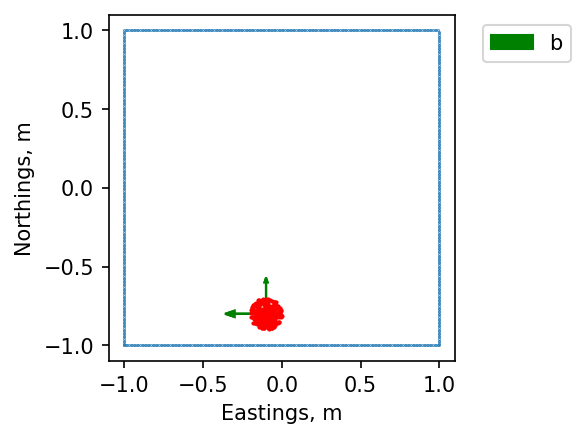

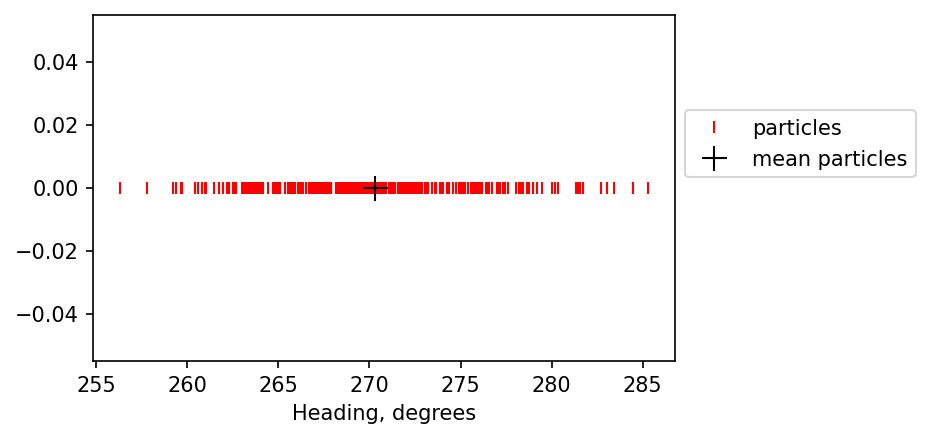

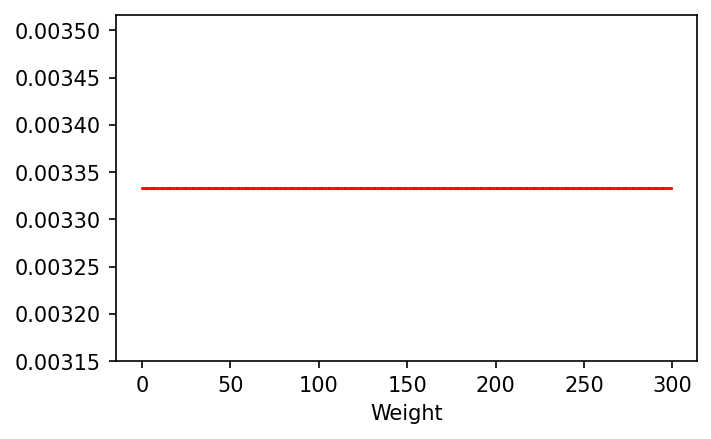

In [6]:
# Create a particle filter
num_particles = 300 #Task
p=p
initial_position_std = 0.1 #Task
auxilliary_noise=[np.deg2rad(5), 0.01, np.deg2rad(3)]  #Task

particle_filter = ParticlePathSLAM(num_particles,
                                 lidar,
                                 p, 
                                 initial_position_std,                                 
                                 auxilliary_noise)

# determine the kde mean state
kde_pose, kde_std = particle_filter.kde_pose(sigma_resolution=0.2, sampling_resolution=100)

# plot the map
fig,ax = plt.subplots()
ax.scatter(m_y, m_x,s=0.1)
Xi = HomogeneousTransformation(p[0:2],p[2]) # plot the ground truth pose
cf=plot_2dframe(['pose_gt','b','b'],[Xi.H,Xi.H],edge_flag = False,legend_flag = True, compact_flag = True) # plot the ground truth pose

# show particles and kde estimate,
particle_filter.show_particles(kde_pose, show_all = True)

**Motion:** Move particles using the discrete motion model within the pf (introduced A2.3 and Tutorial 3 `pf.ipynb`), and move the ground truth with our rigid body motion model (A1.2 and Tutorial `time_motion.ipynb`)

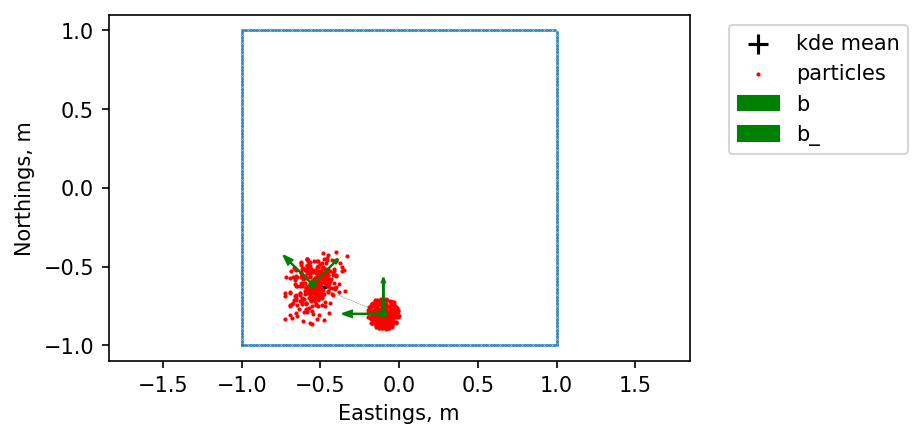

In [7]:
from model_feeg6043 import rigid_body_kinematics

u = Vector(2)
u[0] = 0.1 #m/s linear speed
u[1] = np.deg2rad(9) #rad/s angular speed

dt = 5.0

# plot the environment
plt.scatter(m_y, m_x,s=0.1)


# plot initial particles and ground truth
Xi = HomogeneousTransformation(p[0:2],p[2])
kde_pose, kde_std = particle_filter.kde_pose(sigma_resolution=0.1, sampling_resolution=1000)
particle_filter.show_particles(kde_pose)

# Predict the next positions
particle_filter.predict(u,dt)

# Move the ground truth also
p, _ , _ , _ = rigid_body_kinematics(p,u,dt)

# plot next partciles
Xj = HomogeneousTransformation(p[0:2],p[2])
kde_pose, kde_std = particle_filter.kde_pose(sigma_resolution=0.1, sampling_resolution=1000)
particle_filter.show_particles(kde_pose)


cf=plot_2dframe(['pose_gt','b','b_'],[Xi.H,Xj.H],edge_flag = True,legend_flag = True, compact_flag = True)

##  <span style="color:green">Observation update with GPR</span>

When a particle makes observations that ovelap , it computes the likelihood (and so  weight) of the particle based on how consistent new observations are with what it expects from with previous observations.

This is achieved with Gaussian processes continous map representation. The simulation below is used to demonstrate the different steps. 
- **Task 1:** Run the simulation with motion, observation but no resampling
- **Task 2:** Add the resampling step (i.e., assess particle efficiency, resample as needed (as in a normal PF)
- **Task 3:** Vary sensor beam sampling cap, and particle number to assess performance impact

The only difference to a normal PF is that child particles inherit their parent's map. 

[[ 0.00431393 -0.78539816]
 [ 0.00445982 -0.73123277]
 [ 0.0047634  -0.67706738]
 [ 0.0051614  -0.62290199]
 [ 0.00557584 -0.5687366 ]
 [ 0.00609016 -0.51457121]
 [ 0.0067082  -0.46040582]
 [ 0.00761577 -0.40624043]
 [ 0.00873155 -0.35207504]
 [ 0.00996243 -0.29790965]
 [        nan -0.24374426]
 [        nan -0.18957887]
 [        nan -0.13541348]
 [        nan -0.08124809]
 [        nan -0.0270827 ]
 [        nan  0.0270827 ]
 [        nan  0.08124809]
 [        nan  0.13541348]
 [        nan  0.18957887]
 [        nan  0.24374426]
 [        nan  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
Time is: 0 s, of: 60.1 s
###############################################################
observations
[[ 0.53662867 -0.78539816]
 [ 0.56937698 -0.73123277]
 [ 0.6168746  -0.67706738]
 [ 0.6

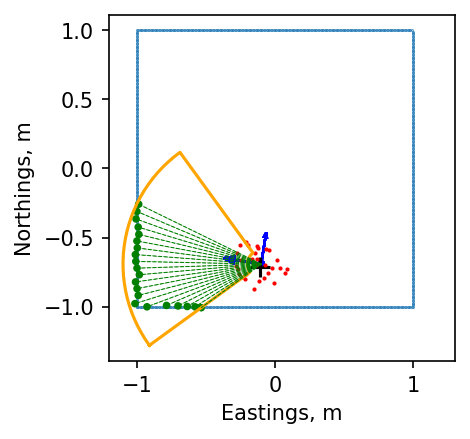

Time is: 1 s, of: 60.1 s
###############################################################
observations
[[ 0.74532295 -0.78539816]
 [ 0.81414461 -0.73123277]
 [ 0.85260006 -0.67706738]
 [ 0.85656487 -0.62290199]
 [ 0.84066077 -0.5687366 ]
 [ 0.82251202 -0.51457121]
 [ 0.80923029 -0.46040582]
 [ 0.818008   -0.40624043]
 [ 0.81399024 -0.35207504]
 [ 0.80095435 -0.29790965]
 [ 0.80338961 -0.24374426]
 [ 0.81780536 -0.18957887]
 [ 0.8184515  -0.13541348]
 [ 0.82737195 -0.08124809]
 [ 0.84828249 -0.0270827 ]
 [ 0.86226667  0.0270827 ]
 [ 0.87638027  0.08124809]
 [ 0.88583152  0.13541348]
 [ 0.91908147  0.18957887]
 [ 0.95504458  0.24374426]
 [ 0.97064499  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.0

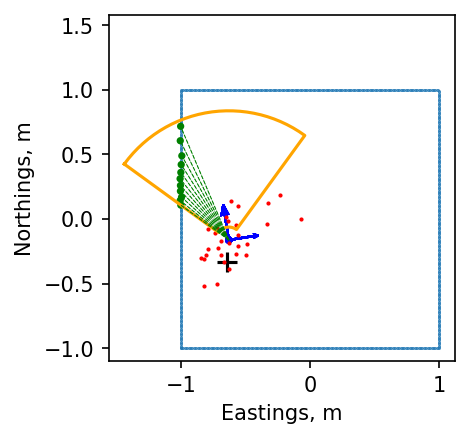

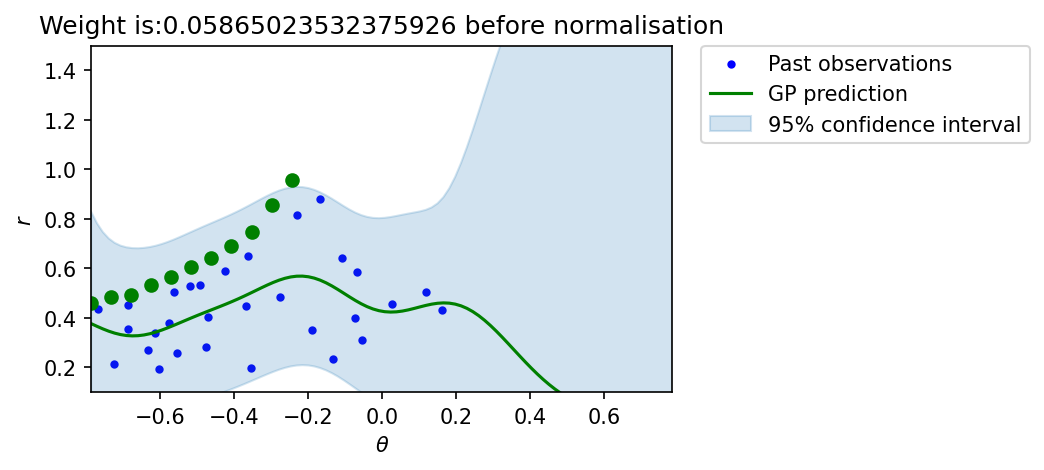

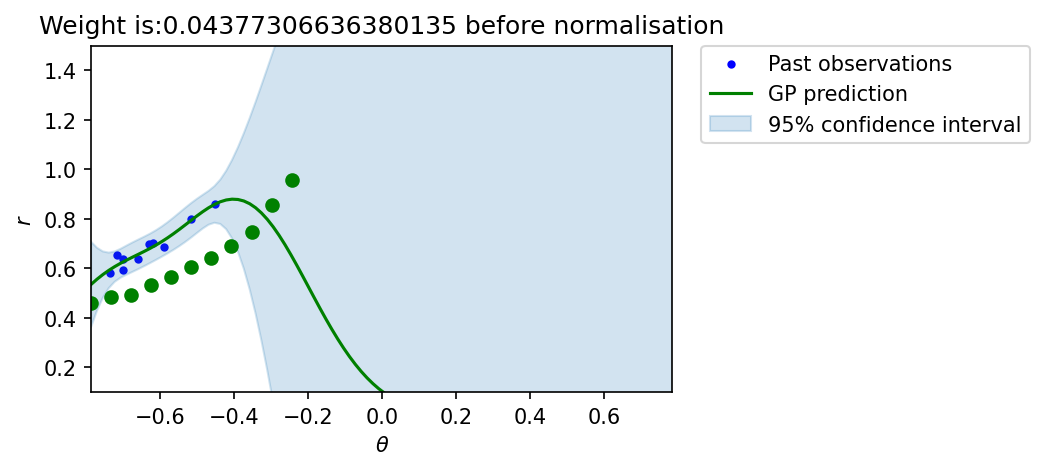

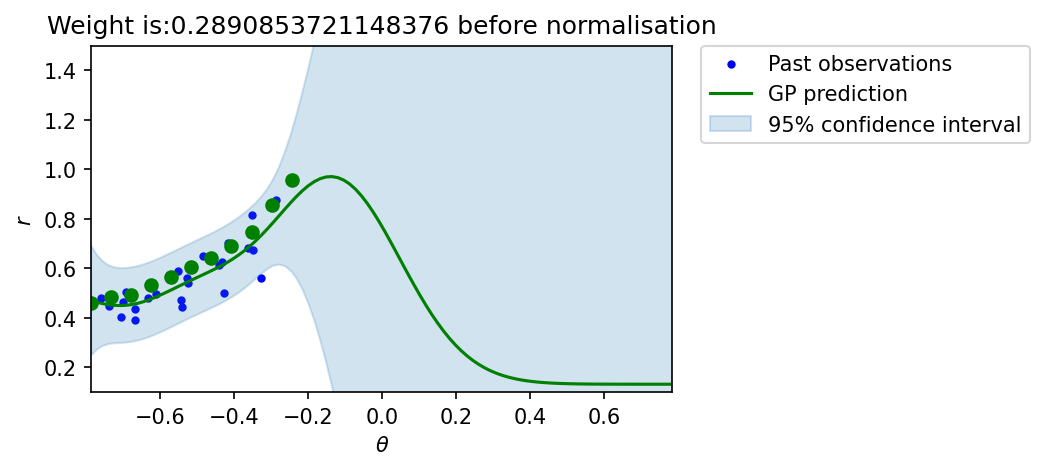

Time is: 9 s, of: 60.1 s
###############################################################
observations
[[ 0.51996391 -0.78539816]
 [ 0.53989625 -0.73123277]
 [ 0.59773907 -0.67706738]
 [ 0.62210736 -0.62290199]
 [ 0.67664635 -0.5687366 ]
 [ 0.73025712 -0.51457121]
 [ 0.82284534 -0.46040582]
 [ 0.93307799 -0.40624043]
 [ 0.9986001  -0.35207504]
 [        nan -0.29790965]
 [        nan -0.24374426]
 [        nan -0.18957887]
 [        nan -0.13541348]
 [        nan -0.08124809]
 [        nan -0.0270827 ]
 [        nan  0.0270827 ]
 [        nan  0.08124809]
 [        nan  0.13541348]
 [        nan  0.18957887]
 [        nan  0.24374426]
 [        nan  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.0

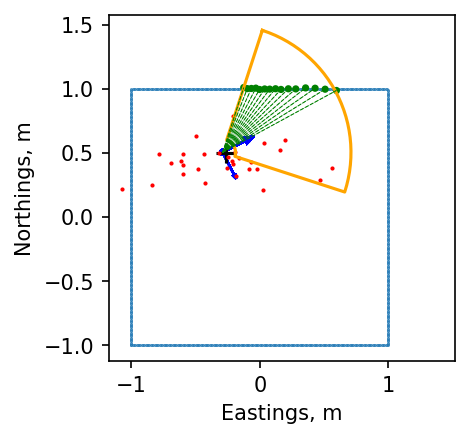

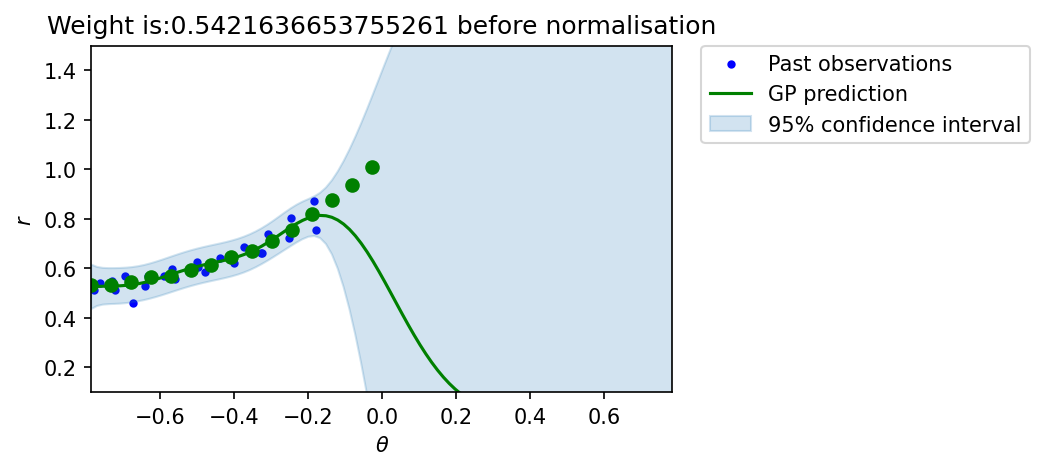

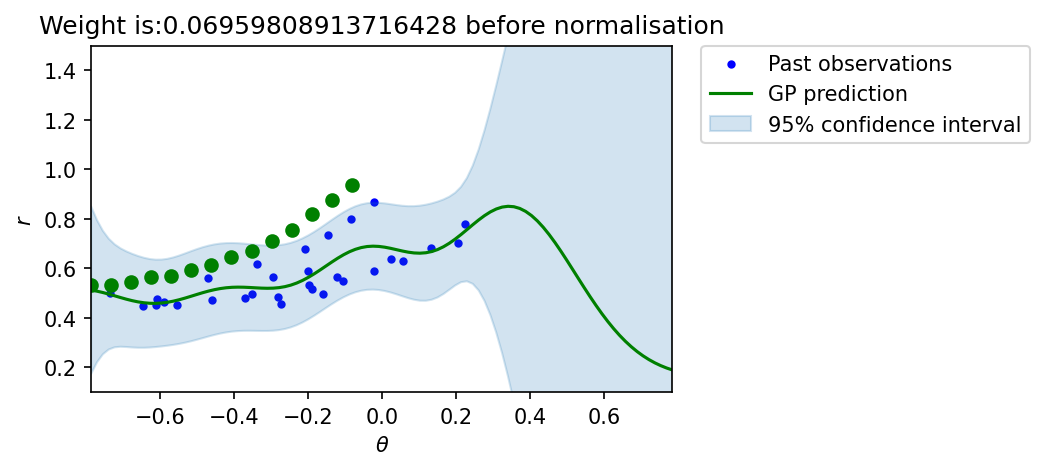

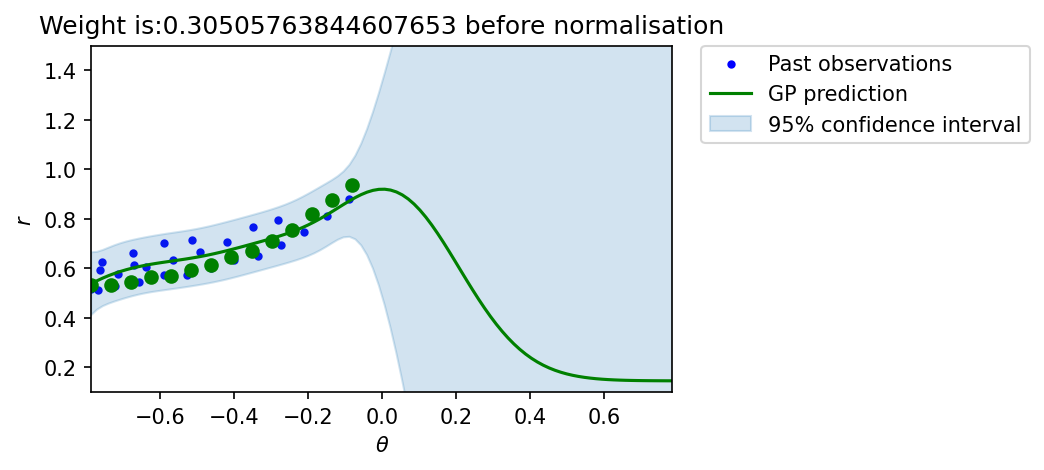

Time is: 17 s, of: 60.1 s
###############################################################
observations
[[ 0.5110803  -0.78539816]
 [ 0.52761452 -0.73123277]
 [ 0.55253613 -0.67706738]
 [ 0.57133495 -0.62290199]
 [ 0.59987503 -0.5687366 ]
 [ 0.61475345 -0.51457121]
 [ 0.65579582 -0.46040582]
 [ 0.68601915 -0.40624043]
 [ 0.74043485 -0.35207504]
 [ 0.79743132 -0.29790965]
 [ 0.88239718 -0.24374426]
 [ 0.9598917  -0.18957887]
 [        nan -0.13541348]
 [        nan -0.08124809]
 [        nan -0.0270827 ]
 [        nan  0.0270827 ]
 [        nan  0.08124809]
 [        nan  0.13541348]
 [        nan  0.18957887]
 [        nan  0.24374426]
 [        nan  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.

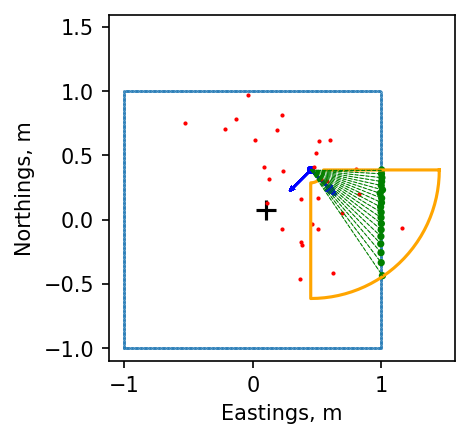

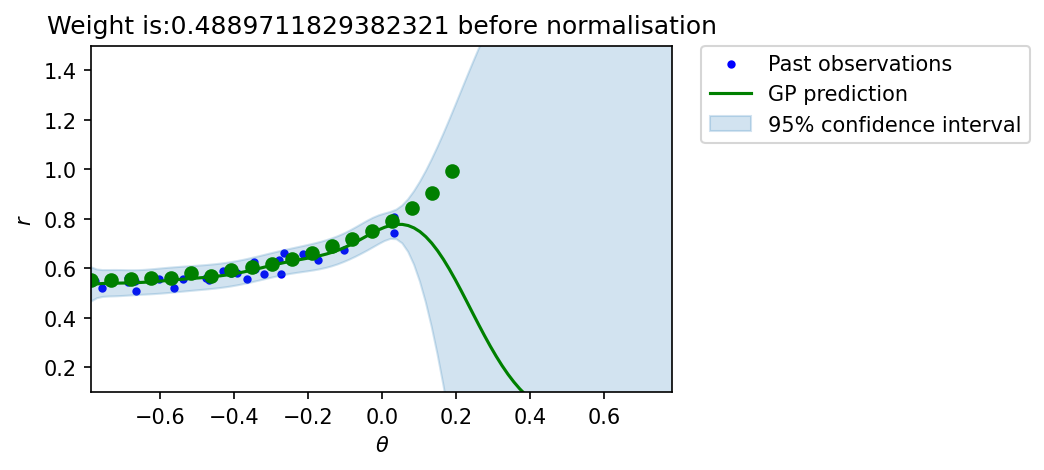

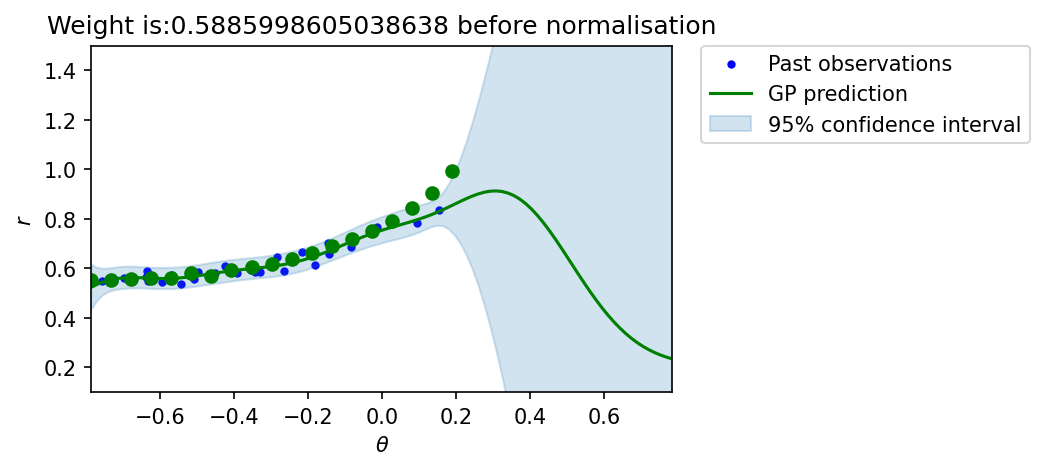

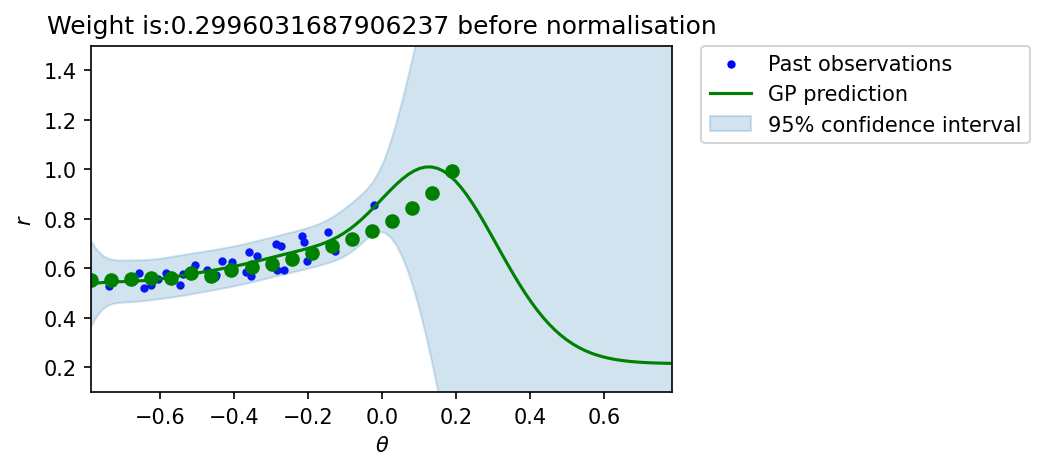

Time is: 25 s, of: 60.1 s
###############################################################
observations
[[ 0.49079668 -0.78539816]
 [ 0.49137675 -0.73123277]
 [ 0.50793611 -0.67706738]
 [ 0.51057074 -0.62290199]
 [ 0.51957513 -0.5687366 ]
 [ 0.54284288 -0.51457121]
 [ 0.54281845 -0.46040582]
 [ 0.56130887 -0.40624043]
 [ 0.58740199 -0.35207504]
 [ 0.60902753 -0.29790965]
 [ 0.63279031 -0.24374426]
 [ 0.66294124 -0.18957887]
 [ 0.70857149 -0.13541348]
 [ 0.73419471 -0.08124809]
 [ 0.79680547 -0.0270827 ]
 [ 0.85811647  0.0270827 ]
 [ 0.94310943  0.08124809]
 [ 0.99230602  0.13541348]
 [        nan  0.18957887]
 [        nan  0.24374426]
 [        nan  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.

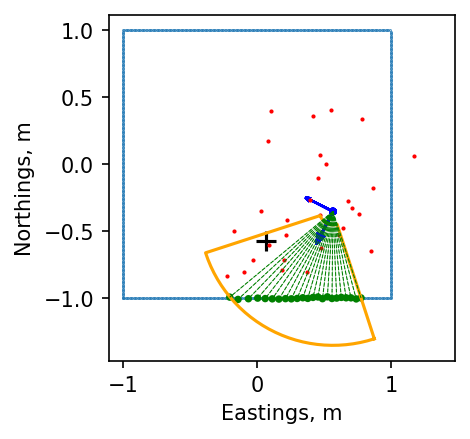

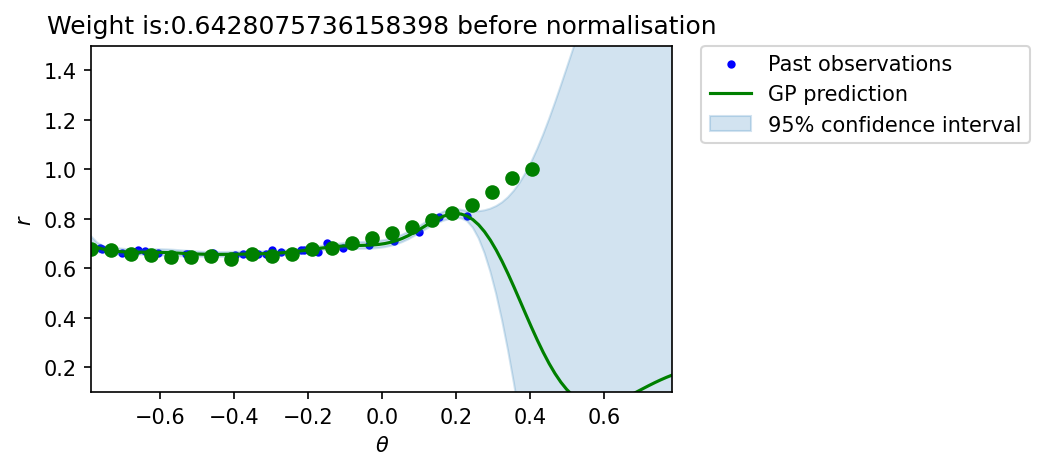

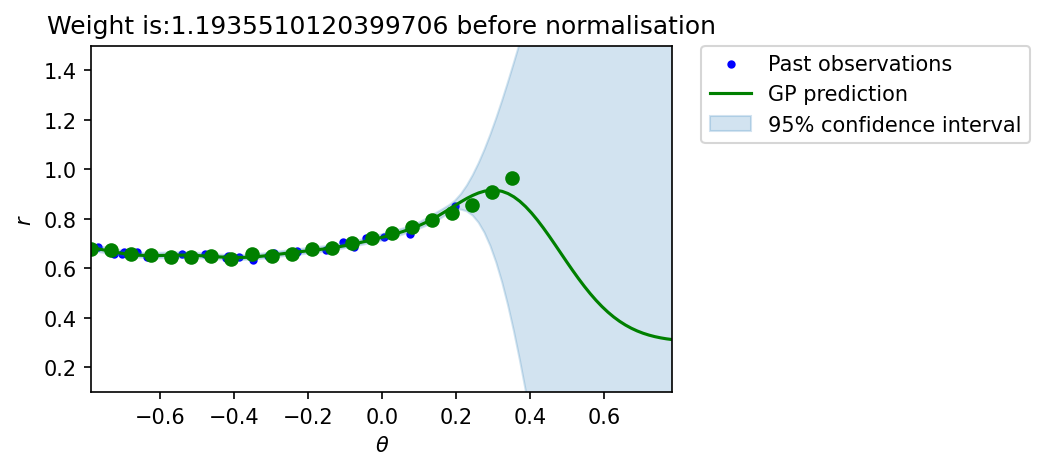

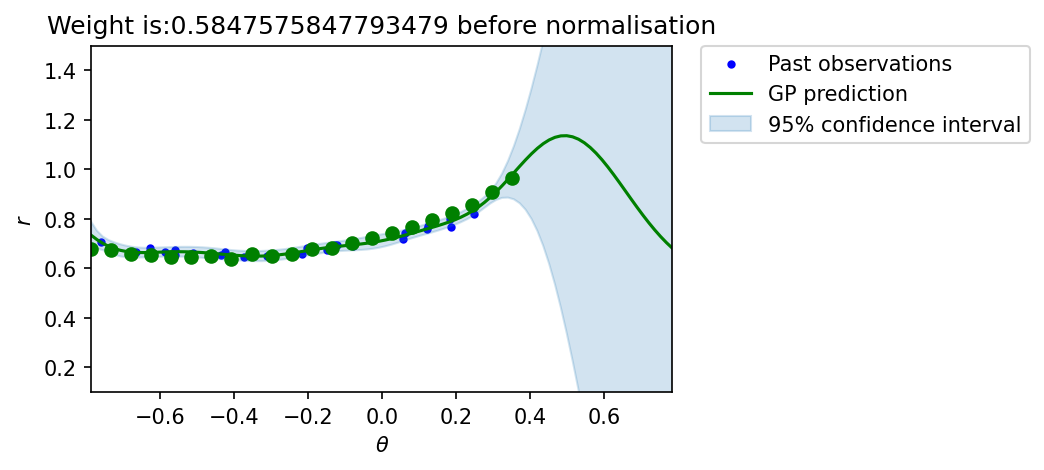

Time is: 33 s, of: 60.1 s
###############################################################
observations
[[ 0.55877836 -0.78539816]
 [ 0.56972793 -0.73123277]
 [ 0.57315956 -0.67706738]
 [ 0.56107903 -0.62290199]
 [ 0.55649978 -0.5687366 ]
 [ 0.56973033 -0.51457121]
 [ 0.55744787 -0.46040582]
 [ 0.57558675 -0.40624043]
 [ 0.58124477 -0.35207504]
 [ 0.6043808  -0.29790965]
 [ 0.61342084 -0.24374426]
 [ 0.63076437 -0.18957887]
 [ 0.63093192 -0.13541348]
 [ 0.66532487 -0.08124809]
 [ 0.68404481 -0.0270827 ]
 [ 0.72143215  0.0270827 ]
 [ 0.7342335   0.08124809]
 [ 0.77533074  0.13541348]
 [ 0.83572392  0.18957887]
 [ 0.8916336   0.24374426]
 [ 0.9555612   0.29790965]
 [ 0.98765657  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.

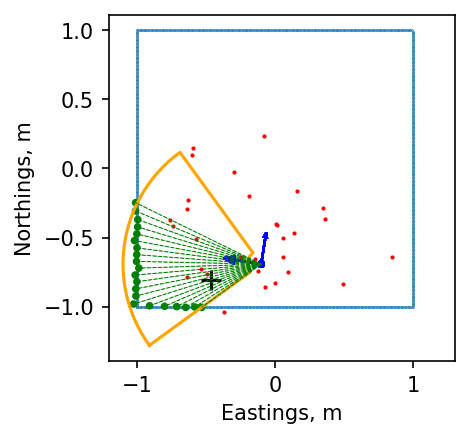

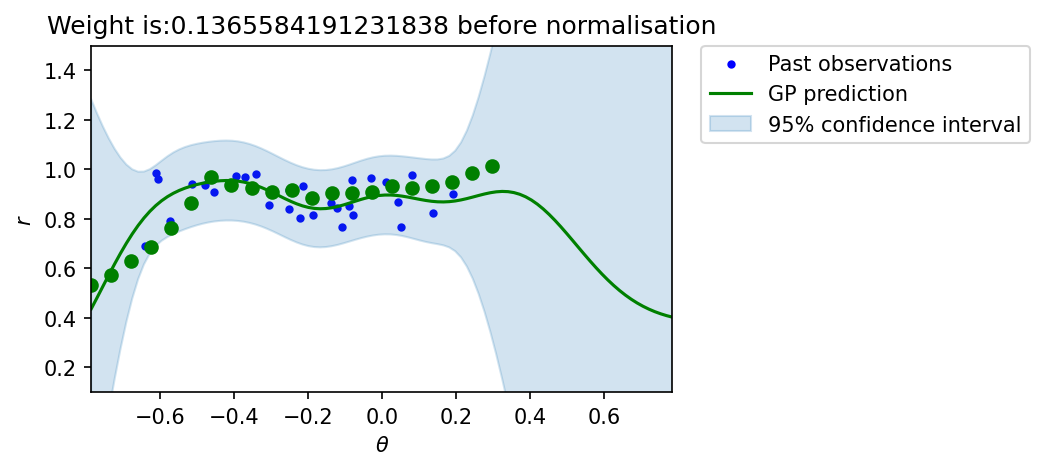

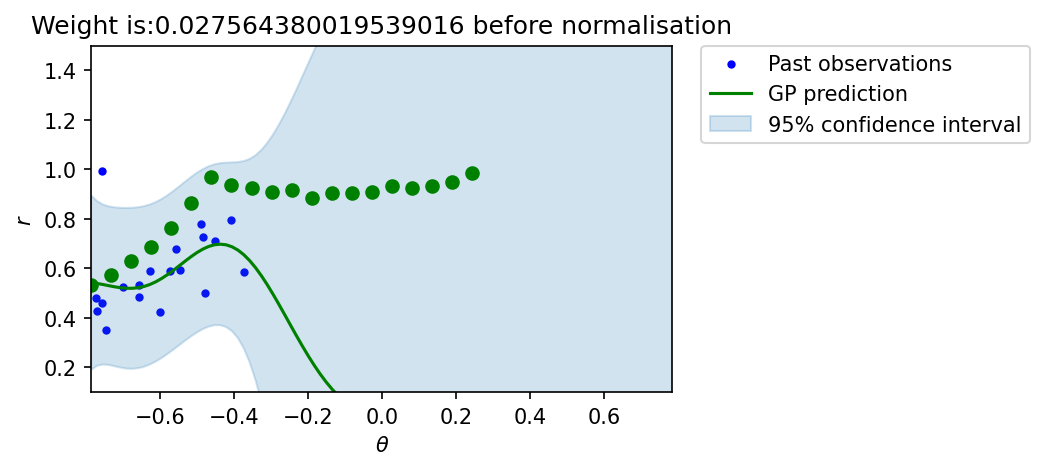

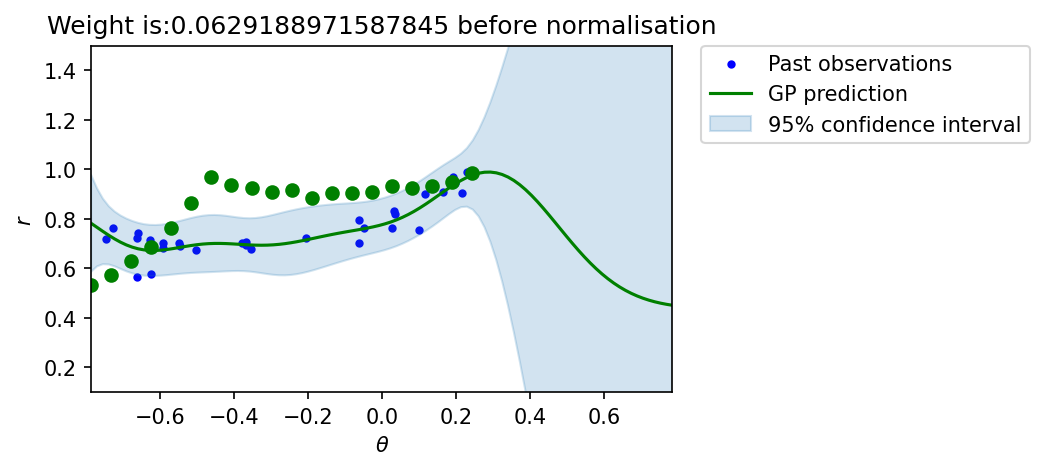

Time is: 41 s, of: 60.1 s
###############################################################
observations
[[ 0.73594328 -0.78539816]
 [ 0.80598896 -0.73123277]
 [ 0.8637842  -0.67706738]
 [ 0.84469048 -0.62290199]
 [ 0.81120106 -0.5687366 ]
 [ 0.81475153 -0.51457121]
 [ 0.8072387  -0.46040582]
 [ 0.81752315 -0.40624043]
 [ 0.8244973  -0.35207504]
 [ 0.81107088 -0.29790965]
 [ 0.80761125 -0.24374426]
 [ 0.8187123  -0.18957887]
 [ 0.81831073 -0.13541348]
 [ 0.82136397 -0.08124809]
 [ 0.83785659 -0.0270827 ]
 [ 0.85502353  0.0270827 ]
 [ 0.87486701  0.08124809]
 [ 0.88722801  0.13541348]
 [ 0.91908702  0.18957887]
 [ 0.95365373  0.24374426]
 [ 0.98516715  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.

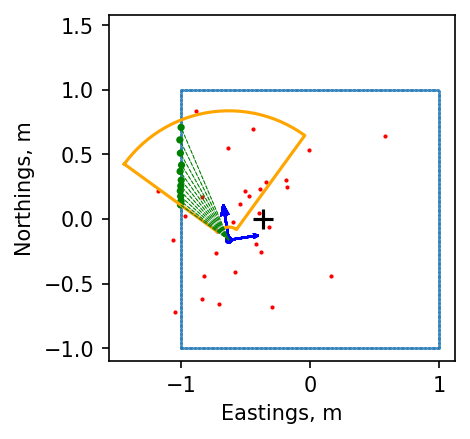

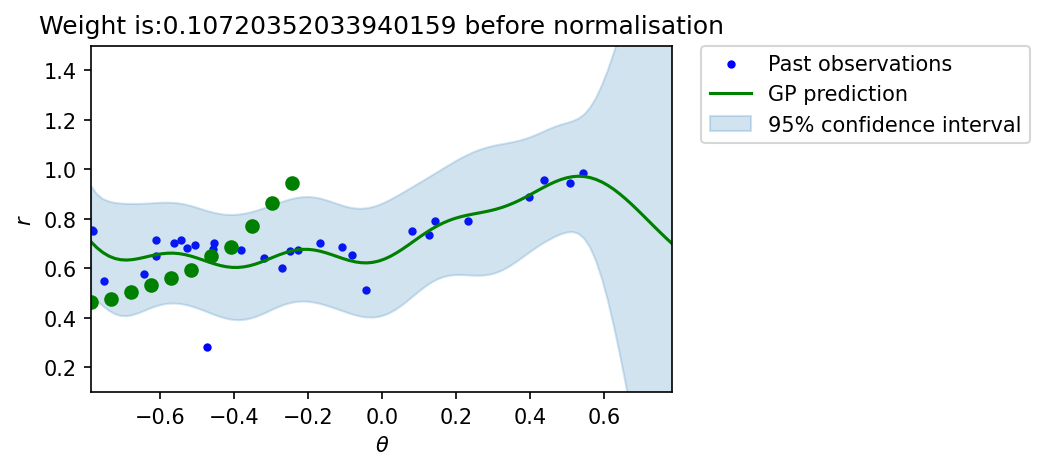

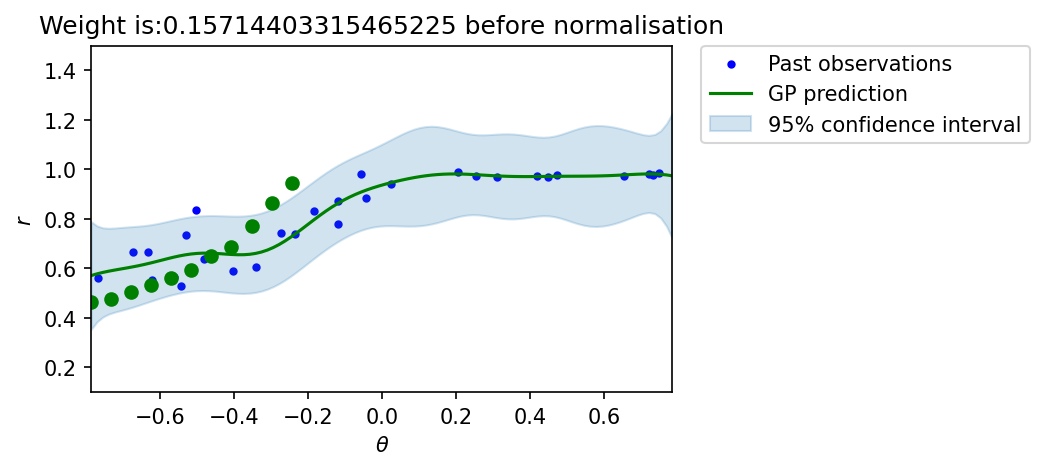

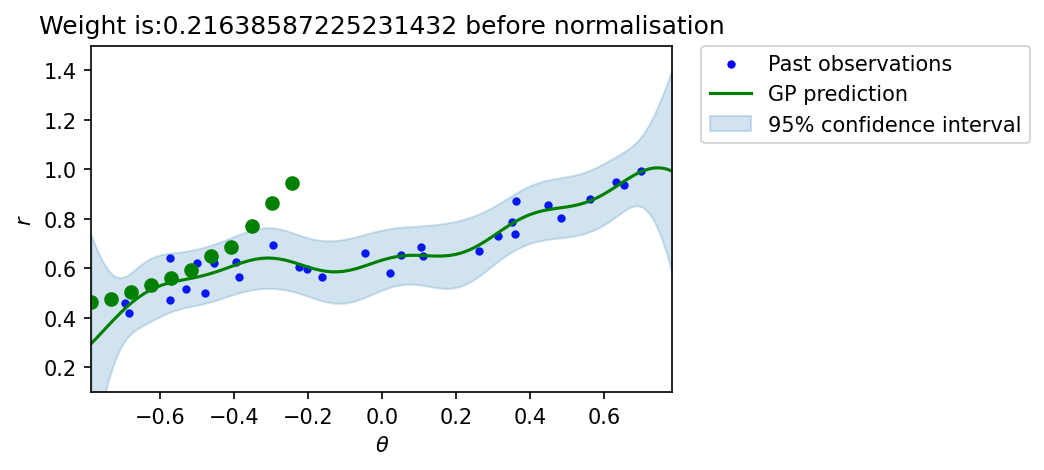

Time is: 49 s, of: 60.1 s
###############################################################
observations
[[ 0.51274443 -0.78539816]
 [ 0.52860568 -0.73123277]
 [ 0.57452848 -0.67706738]
 [ 0.62751267 -0.62290199]
 [ 0.67223941 -0.5687366 ]
 [ 0.7278774  -0.51457121]
 [ 0.80994454 -0.46040582]
 [ 0.93122584 -0.40624043]
 [ 0.99767639 -0.35207504]
 [        nan -0.29790965]
 [        nan -0.24374426]
 [        nan -0.18957887]
 [        nan -0.13541348]
 [        nan -0.08124809]
 [        nan -0.0270827 ]
 [        nan  0.0270827 ]
 [        nan  0.08124809]
 [        nan  0.13541348]
 [        nan  0.18957887]
 [        nan  0.24374426]
 [        nan  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.

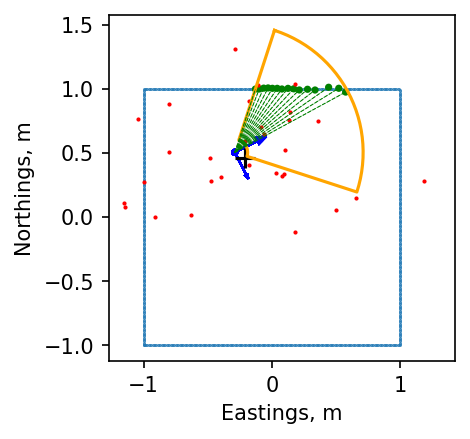

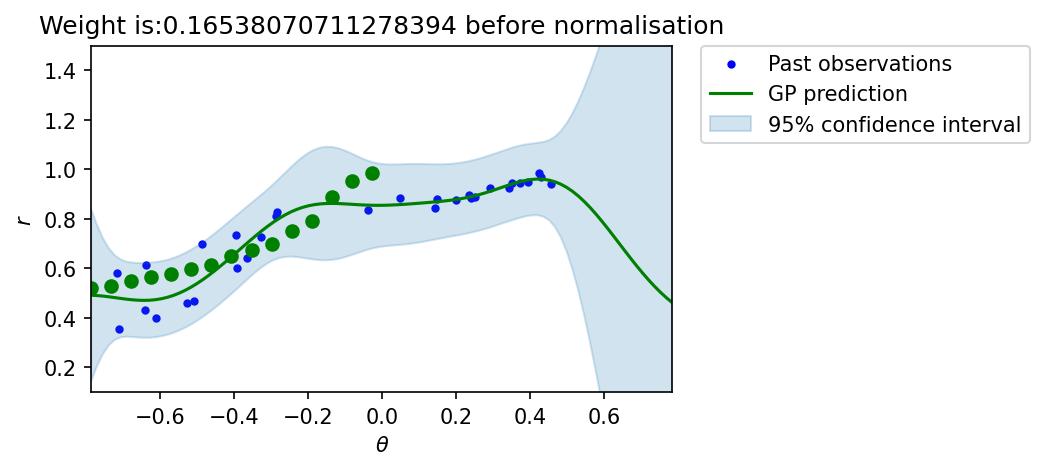

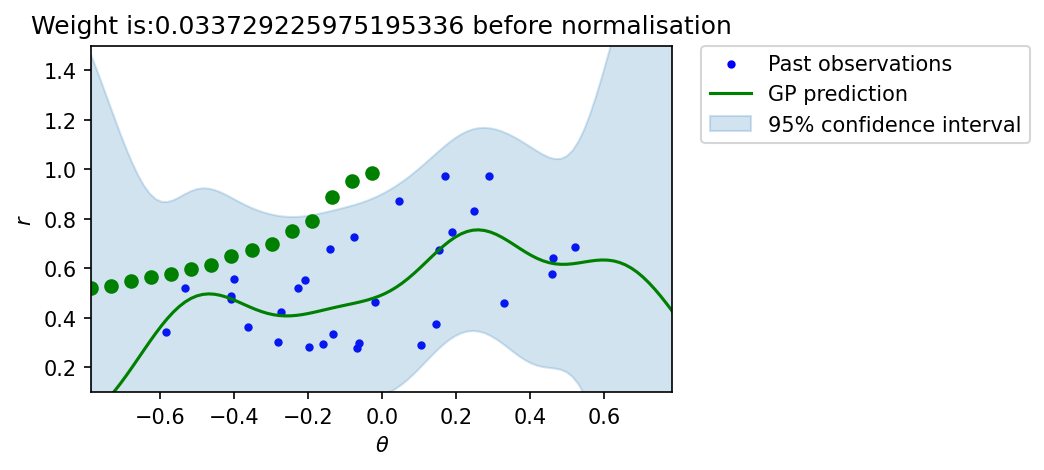

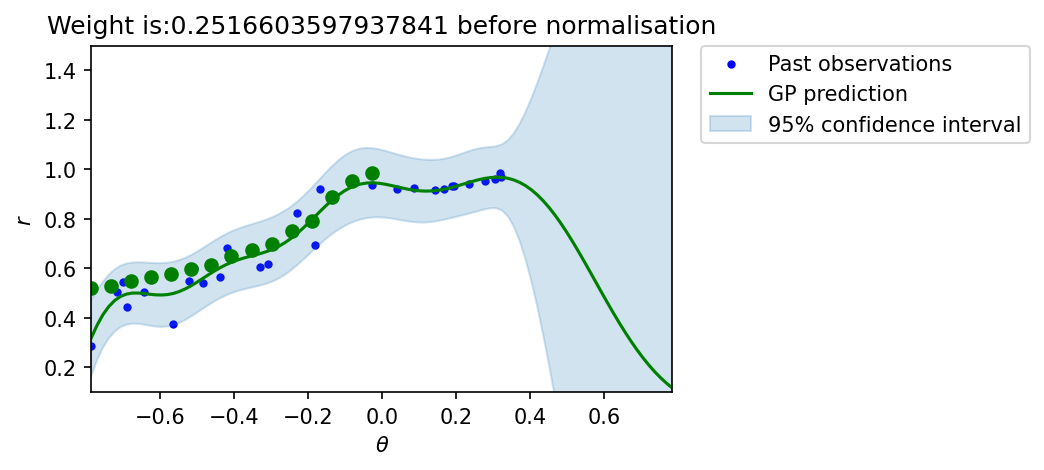

Time is: 57 s, of: 60.1 s
###############################################################
observations
[[ 0.51450739 -0.78539816]
 [ 0.5252949  -0.73123277]
 [ 0.54695009 -0.67706738]
 [ 0.56432694 -0.62290199]
 [ 0.60580797 -0.5687366 ]
 [ 0.62070235 -0.51457121]
 [ 0.65191433 -0.46040582]
 [ 0.6930075  -0.40624043]
 [ 0.74761357 -0.35207504]
 [ 0.80411889 -0.29790965]
 [ 0.8502659  -0.24374426]
 [ 0.9574284  -0.18957887]
 [        nan -0.13541348]
 [        nan -0.08124809]
 [        nan -0.0270827 ]
 [        nan  0.0270827 ]
 [        nan  0.08124809]
 [        nan  0.13541348]
 [        nan  0.18957887]
 [        nan  0.24374426]
 [        nan  0.29790965]
 [        nan  0.35207504]
 [        nan  0.40624043]
 [        nan  0.46040582]
 [        nan  0.51457121]
 [        nan  0.5687366 ]
 [        nan  0.62290199]
 [        nan  0.67706738]
 [        nan  0.73123277]
 [        nan  0.78539816]]
###############################################################
observations_std
[[ 0.

In [10]:
#######################################################################################
# start, end time  and key frames to see intermediate plots 
#######################################################################################
t = 0
dt = 1
t_end = 60.1
key_frames = 8
frames = key_frames

# Create container to store times
T = Vector(1)
T[0,0] = t
#######################################################################################
# Sensor and map parameters (reuse lidar and map from earlier) 
#######################################################################################
gpr_sample_cap = 30 #Task

# map uncertainty can be stored for every observation, but we just set an upperbound 
map_std = sigma_observe[0,0]*lidar.distance_range[1] #max range equivalent
length_scale= 0.2 # GP modelling parameter
#######################################################################################
# Create a particle filter 
#######################################################################################
num_particles = 30 #Task

p = Vector(3) # initial pose
p[0] = -0.7
p[1] = -0.
p[2] = np.deg2rad(270)

position_std = 0.2 # initial spread, resampling spread
auxilliary_noise=[np.deg2rad(5), 0.01, np.deg2rad(3)] #

particle_filter = ParticlePathSLAM(num_particles,
                                 lidar,
                                 p, 
                                 position_std,                                 
                                 auxilliary_noise)

#######################################################################################
# Containors to store actual path, kde_particle_path, observations 
#######################################################################################
P_KDE = Matrix(1,3) #pose
kde_pose, kde_std = particle_filter.kde_pose(sigma_resolution=0.2, sampling_resolution=100)
P_KDE[0,0] = kde_pose[0,0]
P_KDE[0,1] = kde_pose[1,0]
P_KDE[0,2] = kde_pose[2,0]

P_STD = Matrix(1,2) #std
P_STD[0,0] = kde_std[0,0]
P_STD[0,1] = kde_std[1,0]

P_GT = Matrix(1,3) #pose
P_GT[0,0] = p[0,0]
P_GT[0,1] = p[1,0]
P_GT[0,2] = p[2,0]

observations, observations_std = lidar_scan(p, environment_map, lidar, sigma_observe)
print (observations_std)
observations_all = [observations]
#################################################################
# Main simulation loop
#################################################################
plt.figure()
resampling_flag = False #False, True
 

while t < t_end:          

    print('Time is:',t,'s, of:',t_end,'s')
    # Predict 
    particle_filter.predict(u,dt) # motion of particles 
    kde_pose, kde_std = particle_filter.kde_pose(sigma_resolution=0.1, sampling_resolution=100)
    
    p,_,_,_ = rigid_body_kinematics(p,u,dt) # motion of particles 

    # compute observations with noise
    observations, observations_std = lidar_scan(p, environment_map, lidar, sigma_observe)   
    print("###############################################################")
    print("observations")
    print(observations)
    print("###############################################################")
    print("observations_std")
    print(observations_std)
    print("###############################################################")

    # Show particles and scan at key_frames  
    if frames == key_frames:        
        plt.clf()
        plt.scatter(m_y, m_x,s=0.1)
        show_scan(p, lidar, observations,ax)      
        particle_filter.show_particles(kde_pose, False)    
        # update particles with observations
        show_plot=True
        frames = 0
    else: show_plot=False

    # update weights, show_plot shows the GPR weight calculation
    particle_filter.observation_update(observations, observations_std, map_std, length_scale, resampling_flag = False, gpr_sample_cap = gpr_sample_cap
,show_plot=show_plot)
    
    # progress the timestamps
    t = t+dt
    frames += 1

    # store in matrices
    T = np.vstack((T,t))  
    P_KDE = np.vstack((P_KDE,[kde_pose[0,0], kde_pose[1,0], kde_pose[2,0]]))
    P_STD = np.vstack((P_STD,[kde_std[0,0], kde_std[1,0]]))
    P_GT = np.vstack((P_GT,[p[0,0], p[1,0], p[2,0]]))    
    observations_all.append(observations)    
    plt.pause(0.1)

Ground truth path and observations


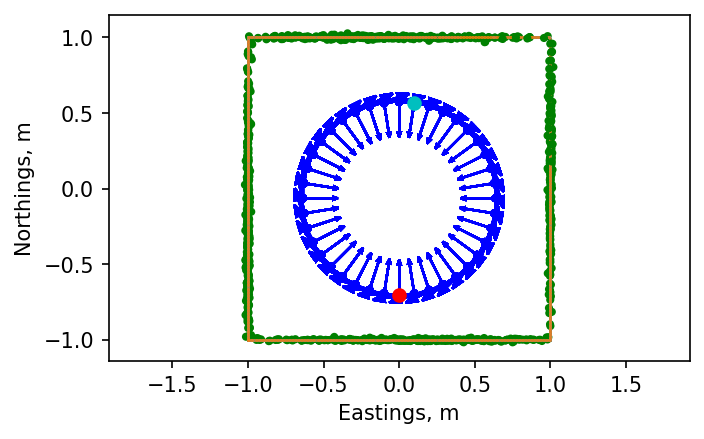

Particle Path SLAM path and observations


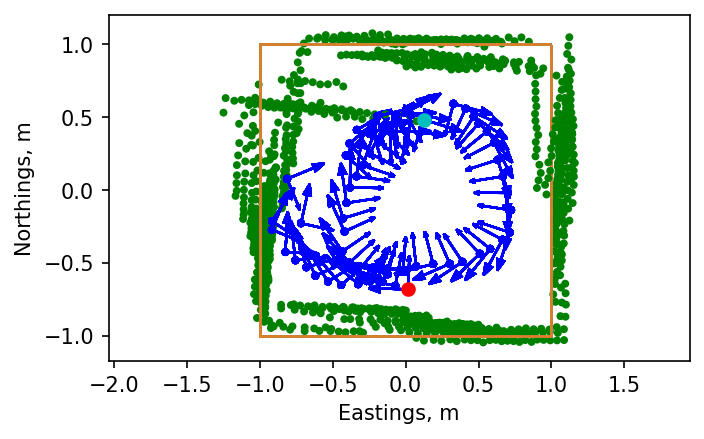

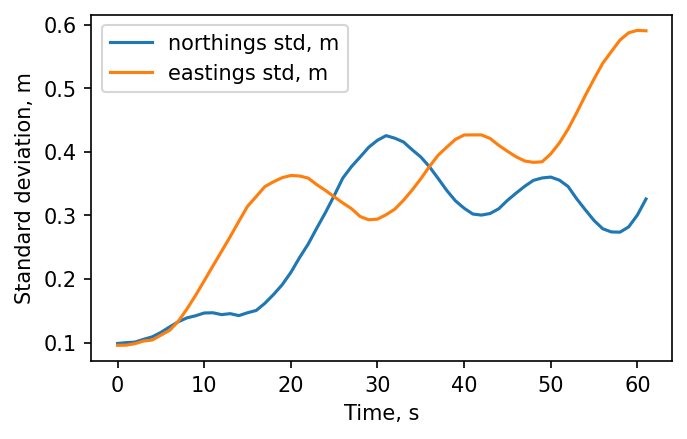

In [ ]:
print('Ground truth path and observations')
for i in range(len(P_GT)):
    p = P_GT[[i],0:3].T    
    plt.scatter(m_y, m_x,s=0.1)
    show_scan(p, lidar, observations_all[i], ax,  show_lines = False)

plt.scatter(P_GT[[0],1], P_GT[[0],0], c='r')
plt.scatter(P_GT[[-1],1], P_GT[[-1],0], c='c')
plt.show()
    
print('Particle Path SLAM path and observations')
for i in range(len(P_GT)):
    p = P_KDE[[i],0:3].T    
    plt.scatter(m_y, m_x,s=0.1)
    show_scan(p, lidar, observations_all[i], ax, show_lines = False)

plt.scatter(P_KDE[[0],1], P_KDE[[0],0], c='r')
plt.scatter(P_KDE[[-1],1], P_KDE[[-1],0], c='c')
plt.show()    

plt.plot(T,P_STD[:,0], label = 'northings std, m')
plt.plot(T,P_STD[:,1], label = 'eastings std, m')
plt.xlabel('Time, s')
plt.ylabel('Standard deviation, m')
plt.legend()
plt.show()    

## <span style="color:green"> Wrap up

You should now:
- Understand the motivations for feature-less SLAM
- Understand theory for Gaussian process regression based weight updates for encoded map observations
- Be able to apply particle filter based feature-less SLAM to simple mobile robotic scenarios